In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum, auto
from tqdm import tqdm
from statistics import mean

In [16]:
# Constants
NUM_NODES = 50
NUM_EDGES = 3
NUM_SIMULATIONS = 100
NUM_TIME_STEPS = 1000
BETA = 0.3
GAMMA = 0.6
G_VALUES = list(np.linspace(0, 1, 10))

In [17]:
def find_largest_neighbor(graph, node):
    neighbors = list(graph.neighbors(node))
    return max(neighbors, key=lambda n: graph.degree(n), default=None) if neighbors else None

def simulate_infection_with_immunity(network, infection_rate, recovery_rate, initial_infected_node, immune_nodes):
    infected = {initial_infected_node}
    probabilities_infected_list = []
    for _ in range(NUM_TIME_STEPS):
        infected = update_infected_set(network, infected, immune_nodes, infection_rate, recovery_rate)
        probabilities_infected_list.append(len(infected) / len(network.nodes()))

    return mean(probabilities_infected_list) if probabilities_infected_list else 0

def update_infected_set(network, infected, immune_nodes, infection_rate, recovery_rate):
    new_infected = infected.copy()
    for infected_node in infected:
        if np.random.rand() < recovery_rate:
            new_infected.remove(infected_node)
        infect_neighbors(network, infected_node, new_infected, immune_nodes, infection_rate)
    return new_infected

def infect_neighbors(network, node, infected, immune_nodes, infection_rate):
    for neighbor in set(network.neighbors(node)).difference(infected, immune_nodes):
        if np.random.rand() < infection_rate:
            infected.add(neighbor)

def select_immune_nodes(graph, fraction, strategy):
    if not graph.nodes:
        return set()

    graph_nodes = list(graph.nodes())
    np.random.shuffle(graph_nodes)
    num_node_selection = int(fraction * len(graph.nodes()))
    if strategy == ImmunisationStrategy.RANDOM:
        return set(np.random.choice(graph_nodes, num_node_selection, replace=False))

    # For TARGETED, avoid calling find_largest_neighbor twice
    return {find_largest_neighbor(graph, node) for node in graph_nodes[:num_node_selection] if find_largest_neighbor(graph, node)}

def perform_infection_simulations_with_immunity(graph, strategy):
    probabilities_infected = []
    for g in tqdm(G_VALUES, desc=f"Progress {strategy} strategy: "):
        immune_nodes = select_immune_nodes(graph, g, strategy)
        probabilities_avg = [simulate_infection_with_immunity(graph, BETA, GAMMA, np.random.choice(list(graph.nodes())), immune_nodes) for _ in range(NUM_SIMULATIONS)]
        probabilities_infected.append(mean(probabilities_avg))
    return probabilities_infected

def generate_barabasi_albert_graph():
    graph = nx.barabasi_albert_graph(n=NUM_NODES, m=NUM_EDGES)
    immunity_random = perform_infection_simulations_with_immunity(graph, ImmunisationStrategy.RANDOM)
    immunity_targeted = perform_infection_simulations_with_immunity(graph, ImmunisationStrategy.TARGETED)
    return immunity_random, immunity_targeted

def plot_sis_sim():
    immunity_random, immunity_targeted = generate_barabasi_albert_graph()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set(title="SIS Simulation: Random vs Targeted Immunization", xlabel="g", ylabel=r"$p^I(t \approx \infty)$", ylim=(0, 1), xlim=(0, 1))
    ax.plot(G_VALUES, immunity_random, label="Random", linestyle='-', color='blue', marker="o", ms=2)
    ax.plot(G_VALUES, immunity_targeted, label="Targeted", linestyle='--', color='green', marker="o", ms=2)
   

Progress ImmunisationStrategy.TARGETED strategy: 100%|██████████| 10/10 [00:49<00:00,  5.00s/it]


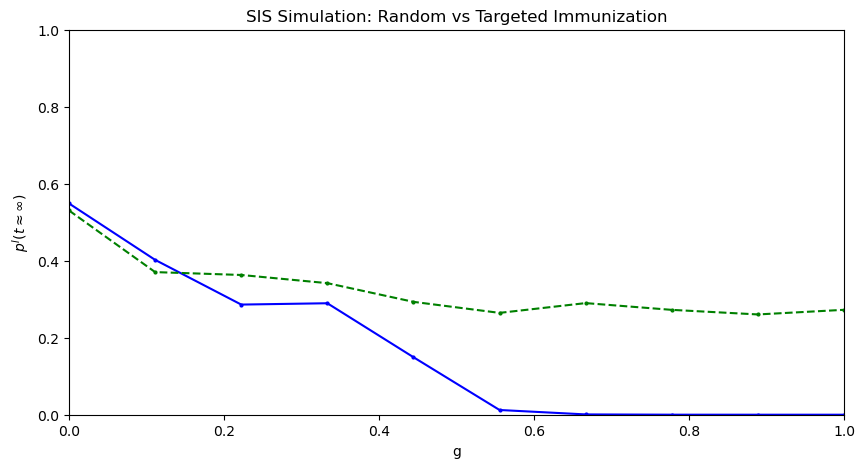

In [18]:
plot_sis_sim()
plt.show()

In [8]:
class ImmunisationStrategy(Enum):
    RANDOM = auto()
    TARGETED = auto()

In [9]:
def find_largest_neighbor(graph, node):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return None

    return max(neighbors, key=lambda n: graph.degree(n), default=None)

def simulate_infection_with_immunity(network, infection_rate, recovery_rate, initial_infected_node, immune_nodes, time_steps=10): #1000
    infected = {initial_infected_node}
    probabilities_infected_list = []

    current_step = 0
    while current_step < time_steps:
        for infected_node in infected.copy():
            if np.random.rand() < recovery_rate:
                infected.remove(infected_node)

            notImmunizedNeigh = set(network.neighbors(infected_node)).difference(immune_nodes)

            for neighbor in notImmunizedNeigh.difference(infected):
                if np.random.rand() < infection_rate:
                    infected.add(neighbor)

        probability_infected = len(infected) / len(network.nodes())

        probabilities_infected_list.append(probability_infected)

        current_step += 1

    if len(probabilities_infected_list) > 0:
        res = mean(probabilities_infected_list)
    else:
        res = 0

    return res

def select_immune_nodes(graph, fraction, strategy):
    graph_nodes = list(graph.nodes())
    np.random.shuffle(graph_nodes)
    num_node_selection = int(fraction * len(graph.nodes()))

    if strategy == ImmunisationStrategy.RANDOM:
        immune_nodes = set(np.random.choice(graph_nodes, num_node_selection, replace=False))
    elif strategy == ImmunisationStrategy.TARGETED:
        immune_nodes = {find_largest_neighbor(graph, node) for node in graph_nodes[:num_node_selection] if find_largest_neighbor(graph, node) is not None}
    else:
        raise ValueError("Invalid immunisation strategy")

    return immune_nodes

In [10]:
def perform_infection_simulations_with_immunity(graph, infection_rate, recovery_rate, immunity_fractions, immunity_strategy):
    num_simulations = 100
    num_time_steps = 1000

    probabilities_infected = []

    for g in tqdm(immunity_fractions, desc=f"Progress {immunity_strategy} strategy: "):
        probabilities_avg = simulate_infections_for_fraction(graph, num_simulations, infection_rate, recovery_rate, immunity_strategy, g, num_time_steps)
        probabilities_infected.append(mean(probabilities_avg))

    return probabilities_infected, num_simulations, num_time_steps


def simulate_infections_for_fraction(graph, num_simulations, infection_rate, recovery_rate, immunity_strategy, g, num_time_steps):
    probabilities_avg = []

    for _ in range(num_simulations):
        initial_infected_node = np.random.choice(list(graph.nodes()))
        immune_nodes = select_immune_nodes(graph, g, immunity_strategy)
        probability_infected = simulate_infection_with_immunity(
            network=graph,
            infection_rate=infection_rate,
            recovery_rate=recovery_rate,
            initial_infected_node=initial_infected_node,
            immune_nodes=immune_nodes,
            time_steps=num_time_steps,
        )
        probabilities_avg.append(probability_infected)

    return probabilities_avg

In [13]:
def generate_barabasi_albert_graph():
    graph = nx.barabasi_albert_graph(n=50, m=3)
    g_values = list(np.linspace(0, 1, 10))
    beta, gamma = 0.3, 0.6

    # Unpack the results from the RANDOM strategy
    random_probabilities_infected, random_num_simulations, random_num_time_steps = perform_immunization_simulations(graph, beta, gamma, ImmunisationStrategy.RANDOM, g_values)

    # Unpack the results from the TARGETED strategy
    targeted_probabilities_infected, targeted_num_simulations, targeted_num_time_steps = perform_immunization_simulations(graph, beta, gamma, ImmunisationStrategy.TARGETED, g_values)

    return random_probabilities_infected, targeted_probabilities_infected, g_values, random_num_simulations, random_num_time_steps


def perform_immunization_simulations(graph, beta, gamma, strategy, g_values):
    return (*perform_infection_simulations_with_immunity(graph, beta, gamma, g_values, strategy),)


Progress ImmunisationStrategy.TARGETED strategy: 100%|██████████| 10/10 [00:28<00:00,  2.82s/it]


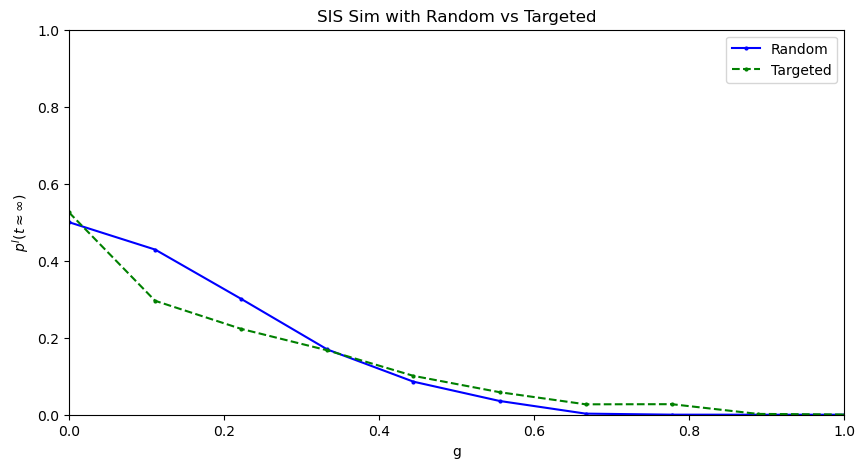

In [15]:
def plot_sis_sim():
    immunity_random, immunity_targeted, g, num_simulations, num_time_steps = generate_barabasi_albert_graph()

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.set(title="SIS Sim with Random vs Targeted", xlabel="g", ylabel=r"$p^I(t \approx \infty)$", ylim=(0, 1), xlim=(0, 1))
    ax.plot(g, immunity_random, label="Random", linestyle='-', color='blue', marker="o", ms=2)
    ax.plot(g, immunity_targeted, label="Targeted", linestyle='--', color='green', marker="o", ms=2)
    ax.legend()

plot_sis_sim()
plt.show()